# Plot Tutorials 

## Introduction

This set of tutorials demonstrates several types of plots using python's built in plotting packages. The example model used here to generate the data and simulations for plots is the same as the example model used in the introductory IQ videos and other notebook examples.

## Table of Contents
1. [Tornado Plot](#Tornado-Plot)
   - One-at-a-time sensitivity analysis
2. [Predicted vs Observed](#Predicted-vs-Observed)
    - Data vs simulation plot
    - Distribution of residuals
3. [Heat Map](#Heat-Map)
    - 2 dimensional sensitivity analysis
4. [Text Labels](#Text-Labels)
    - Adding text labeling to a plot 

# Load packages

All examples use the same packages

In [1]:
from plotnine import *
import abm
import numpy as np
import pandas as pd
import scipy.stats as stats

# Tornado Plot
This example demonstrates how to perform a one-at-a-time sensitivity analysis of a two‑compartment pharmacokinetic/pharmacodynamic (PK/PD) model and visualise the results with a tornado plot using the `plotnine` library. The goal of this sensitivity analysis is to determine which parameters the desired output (in this case RO) is most sensitive to. This is done by varying each scanned parameter by the same fold change up and down and comparing how the model output is affected.

## Tutorial Steps

1. Define dose and simulation tables: A single sub‑cutaneous (SC) dose of 3 mg/kg is chosen for the analysis. See Introduction to Analyze material for more details.
2. Perform one-at-a-time sensitivity scans: Use the scan_fold option to simulate the effect of changing each parameter by the same fold difference. See Introduction to Parameter Scans for more details.
3. Create a tornado plot to visualize the results: A custom `tornado_plot` function is defined. This function has several optional inputs that can be customized depending on your needs.

## Set up & Simulation
- Load model and nominal parameter sets
    - Dosing parameters from model diagram are programmatically set to zero to avoid double dosing. See intro to Analyze video for more details
- Programatically define dose and simulation table
- Simulate parmeter scans over x0.5, x1, x2 fold parameter changes for parameters:
    - central volume, peripheral volume, binding on rate, affinity, drug elimination, receptor turnover, drug distribution, receptors in central compartment, receptors in peripheral compartment, bioavailability, and absoprtion half time

In [2]:
model = 'inputs/Models/2compartment_Ab.iqd'
Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')
Tpar = pd.concat([Tpar,
                  pd.DataFrame({'parameter':['Dose_amt_IV',
                                             'Dose_amt_SC']}).assign(unit = 'mg/kg',
                                                                     value = 0,
                                                                     is_fit = 'False')])

doses = [10]
times_single = [0]

Tdos = pd.DataFrame({'dose_mpk':doses,
                            'amounts': doses,
                            'times': [times_single] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg',
                                                                                route = 'Dose_SC')
Tsim = Tdos[['dose_mpk']]

Tsens = abm.simulate(models = model,
        parameters = Tpar,
        doses = Tdos,
        simulations = Tsim,
        outputs = ['RO_c'],
        times = ['35:d'],
        scans = abm.fold_scan(Volume_c = [0.5, 1, 2])
                 + abm.fold_scan(Volume_p = [0.5, 1, 2])
                 + abm.fold_scan(kon = [0.5, 1, 2])
                 + abm.fold_scan(Kd = [0.5, 1, 2])
                 + abm.fold_scan(Thalf = [0.5, 1, 2])
                 + abm.fold_scan(Thalf_R = [0.5, 1, 2])
                 + abm.fold_scan(Pdist = [0.5, 1, 2])
                 + abm.fold_scan(Tdist = [0.5, 1, 2])
                 + abm.fold_scan(Receptors_c = [0.5, 1, 2])
                 + abm.fold_scan(Receptors_p = [0.5, 1, 2])
                 + abm.fold_scan(F = [0.5, 1, 2])
                 + abm.fold_scan(Thalf_abs = [0.5, 1, 2])
                ).to_pandas(tall_outputs = True)[['param_scan_0', 'scan_0_fold', 'value']]

Total: 0, Running: 0, Succeeded: 0, Failed: 0

In [3]:
#display "head" of resulting output

display(Tsens.head())

,param_scan_0,scan_0_fold,value
0,Volume_c,0.5,27.838667
1,Volume_c,1.0,27.947124
2,Volume_c,2.0,26.579791
3,Volume_p,0.5,51.382358
4,Volume_p,1.0,27.947124


## Define tornado plot function

Function Inputs:
- nominal_value (float): Value of your plotted metric when nominal parameters are chosen
- table (pandas dataframe): Table with the sensitivity analysis you want to plot in a tornado plot
- label_col (string): Column with the names of scanned parameters/inputs. Default = `'param_scan_0'`
- scan_col (string): Column with the scanned input values. Default = `'scan_0_fold'`
- value_col (string): Column with the resulting values. Default = `'value'`
- bar_width (float): Width of bars used in plot
- aspect_ratio (float or None): Ratio of plot height:width. Default = `None`
- label (function or None): function to define color legend label. Default = `None`
- colors (list): List of 2 hex code strings to define color of bars. Default = `['#DDAA33', '#BB5566']`
- color_label (string): Label of color legend. Default = `'Scan Fold'`
- x_label (string): Label for x axis. Default = `'Simulated Value'`
- y_label (string): Label for y axis. Default = `'Scanned Parameter'`
- title (string or None): Title for plot. Default = `'Sensitivity Analysis'`
- subtitle (string or None): Subtitle for plot. Default = `None`

In [4]:
def tornado_plot(nominal_value, table, label_col = 'param_scan_0', scan_col = 'scan_0_fold', value_col = 'value', bar_width = 10,
                aspect_ratio = None, label = None, colors = ['#DDAA33', '#BB5566'],
                color_label = 'Scan Fold', x_label = 'Simulated Value', y_label = 'Scanned Parameter',
                 title = 'Sensitivity Analysis', subtitle = None):
    par_ranges = table.groupby(label_col)[value_col].apply(lambda val: max(val) - min(val)).sort_values()
    ordered_pars = par_ranges.index.tolist()
    
    fig = (ggplot(data = table.query(f'{value_col} != {nominal_value}'))
           + geom_segment(mapping = aes(x = value_col, xend = nominal_value, y = label_col,
                                        yend = label_col, color = f'factor({scan_col})'), size = bar_width)
           + geom_vline(xintercept = nominal_value)
           + scale_color_manual(values = colors,
                                labels = lambda xs: [xi if label == None else label(xi) for xi in xs])
           + scale_y_discrete(limits = ordered_pars)
           + labs(x = x_label, y = y_label, color = color_label, title = title, subtitle = subtitle)
           + theme_bw()
           + theme(aspect_ratio = aspect_ratio, plot_title = element_text(hjust=0.5), plot_subtitle= element_text(hjust=0.5))
           )
    return fig

## Display Tornado plot
- Calculate nominal value as the output value when the `'scan_0_fold` column is equal to 1
- Display a tornado plot using the previously defined function

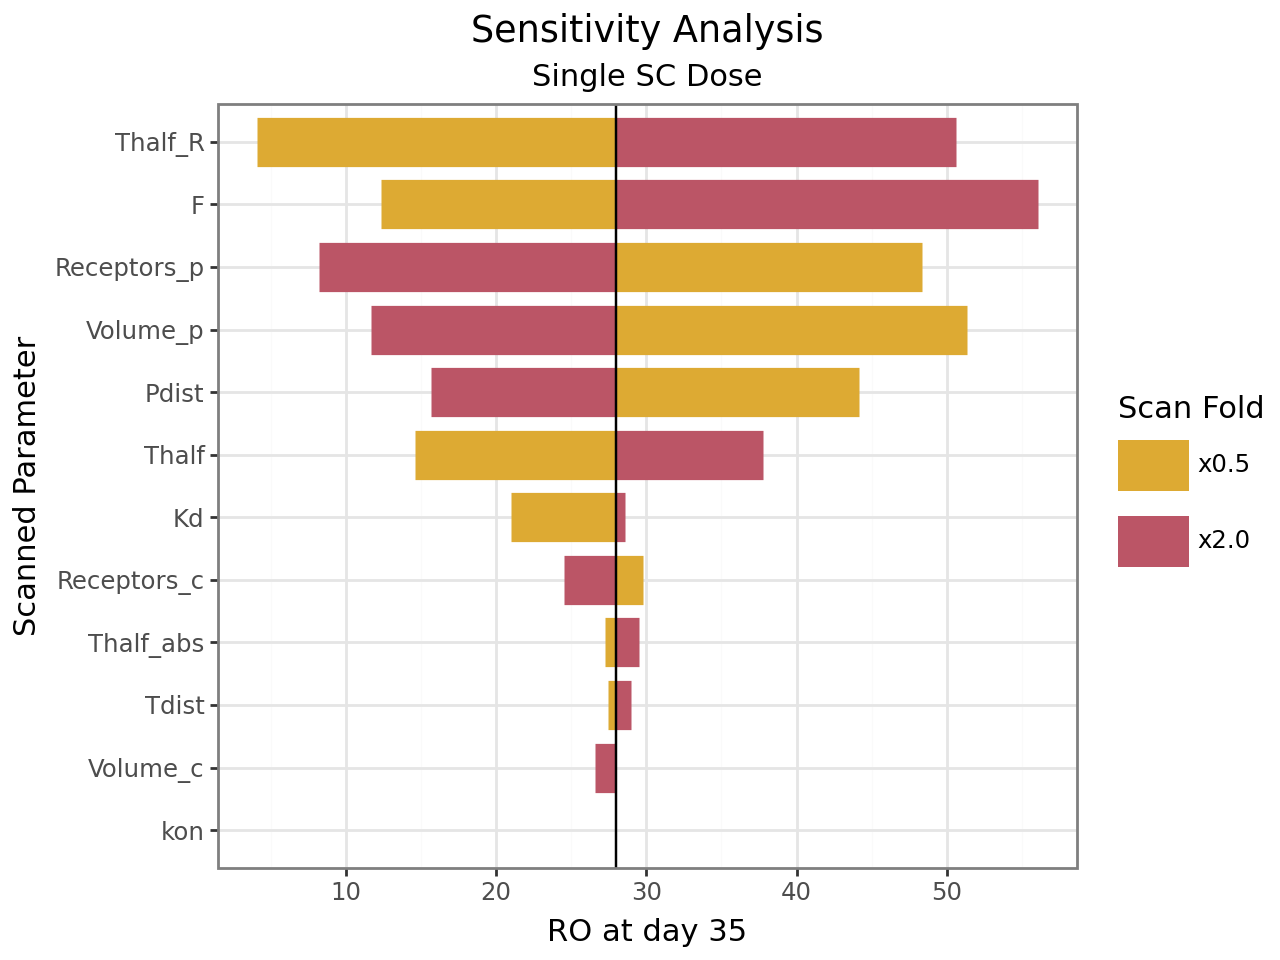

In [5]:
nominal_value = Tsens.query('scan_0_fold == 1').value.unique()[0]
fig = tornado_plot(nominal_value, Tsens, x_label = 'RO at day 35', subtitle = 'Single SC Dose', label = lambda label: f'x{label}')
display(fig)

# Predicted vs Observed

This example demonstrates how to analyze the results of optimization results and compare the best fit simulations to measured data. The goal of this analysis is to compare measured data to predicted simulation values and visualize the distribution of residuals for the best fit simulations. This example uses Python's `plotnine` library for plotting and uses Python's `scipy` library to estimate the density of the residual distribution. Residuals and the log likelihood contribution at each time point are calculated using the `.residuals` function within the `abm` package.

## Tutorial Steps

1. Fit model to data (see Introduction to Optimization tutorial for more details)
2. Plot simulated time points against data
3. Plot histogram of residuals

## Load Model, parameter set, and data

- Load the 2 compartment PK/RO example model from all the training videos and most other introductory notebooks is used here
- Data is loaded
- Load the same parameter table as a nominal set.
    - The dosing parameters from the model file are programmatically set to zero to ensure no double dosing

In [6]:
model = 'inputs/Models/2compartment_Ab.iqd'
Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')

Tdat = pd.read_csv('inputs/Data/Data_example_subset.csv')

Tpar_base = pd.read_csv('inputs/Parameters/Parameter.csv')
Tpar_base = pd.concat([Tpar_base,
                       pd.DataFrame({'parameter':['Dose_amt_IV',
                                                  'Dose_amt_SC']}).assign(unit = 'mg/kg',
                                                                          value = 0,
                                                                          is_fit = 'False')])

## Fit model to data

- Select which parameters to fit
    - Thalf and Pdist are fit to the same value for all patients
    - Receptor counts are fit to unique values for each patient
- Set up parameter table for fitting
- Set up dose table by reading dosing information from data table
- Perform optimization
- Calculate Residuals using the `.residual()` function
    - display first 5 rows of this function

In [7]:
fit_same = ['Thalf','Pdist']
fit_diff = ['Receptors_c', 'Receptors_p']
ID_list = [0,1,2,3]

Tpar_prefit_ind = pd.concat([Tpar_base.query(f'not ((parameter.isin({fit_same})) or (parameter.isin({fit_diff})))').assign(ID = '*'),
                         Tpar_base.query(f'parameter.isin({fit_same})').assign(ID = '*', upper_bound = lambda x: x.value * 100,
                                                                          lower_bound = lambda x: x.value /100, is_fit = True),
                         pd.concat([Tpar_base.query(f'parameter.isin({fit_diff})').assign(ID = i, upper_bound = lambda x: x.value * 100,
                                                                          lower_bound = lambda x: x.value /100, is_fit = True)\
                                    for i in ID_list])
                        ])

Tdos_ind  = Tdat[['dose_mpk', 'ID', 'dose_route']].drop_duplicates()\
    .assign(route = lambda x: x.dose_route, times = str(list(range(0,35,7))), time_unit = 'd',
            amounts = lambda x: x.dose_mpk, amount_unit = 'mg/kg')

opt_ind = abm.optimize(measurements = Tdat,
             parameters = Tpar_prefit_ind,
             doses = Tdos_ind,
             models = 'inputs/Models/2compartment_Ab.iqd')

Total: 0, Running: 0, Succeeded: 0, Failed: 0

iteration,objective,Receptors_c_fit_14,Receptors_p_fit_15,Pdist_fit_12,Thalf_fit_13,Receptors_c_fit_16,Receptors_p_fit_17,Receptors_c_fit_18,Receptors_p_fit_19,Receptors_c_fit_20,Receptors_p_fit_21
0,140.676566,10.000000,50.000000,0.300000,28.000000,10.000000,50.000000,10.000000,50.000000,10.000000,50.000000
1,140.676566,10.000000,50.000000,0.300000,28.000000,10.000000,50.000000,10.000000,50.000000,10.000000,50.000000
2,-216.810994,10.065462,51.717676,0.466072,27.185772,10.367382,63.065446,9.688326,41.700894,9.920627,47.574013
3,-451.487014,9.616257,47.350842,0.363274,30.625098,13.683278,80.707270,8.758743,35.049252,9.186236,41.638660
4,-489.540615,10.414477,53.940878,0.429600,43.809804,12.279300,66.847419,7.585733,29.056171,9.468194,43.162418
5,-511.506751,10.621252,57.367779,0.403152,42.354491,12.431809,71.985519,7.632560,30.485940,9.565654,44.377688
6,-511.506751,10.621252,57.367779,0.403152,42.354491,12.431809,71.985519,7.632560,30.485940,9.565654,44.377688
7,-517.230813,10.576233,55.191821,0.411304,41.962520,12.484323,74.111129,7.685899,31.726098,9.579532,44.825175
8,-517.230813,10.576233,55.191821,0.411304,41.962520,12.484323,74.111129,7.685899,31.726098,9.579532,44.825175
9,-518.665232,10.561366,54.887193,0.405474,41.950347,12.489907,73.813047,7.700351,31.920240,9.570337,44.725987


In [8]:
residuals = opt_ind.residuals().to_pandas()

In [9]:
residuals.head()

,dose_mpk,ID,dose_route,id,time,time_unit,target,measurement,unit,prediction,residual,normalized_residual,log_likelihood
0,3.0,0,Dose_SC,0,2.333333,d,free_drug_p,30.167004,nM,29.181764,0.985240,0.332048,1.328519
1,3.0,0,Dose_SC,0,2.333333,d,free_drug_c,93.650203,nM,101.357811,-7.707608,-0.790903,1.070882
2,3.0,0,Dose_SC,0,4.666667,d,free_drug_p,29.712594,nM,29.386836,0.325758,0.110242,1.377570
3,3.0,0,Dose_SC,0,4.666667,d,free_drug_c,78.968045,nM,78.404926,0.563119,0.071565,1.381086
4,3.0,0,Dose_SC,0,7.000000,d,free_drug_p,24.398284,nM,24.578608,-0.180324,-0.073637,1.380935


## Plot predicted vs observed
- Plot Predicted vs Observed values
- Color code by patient ID

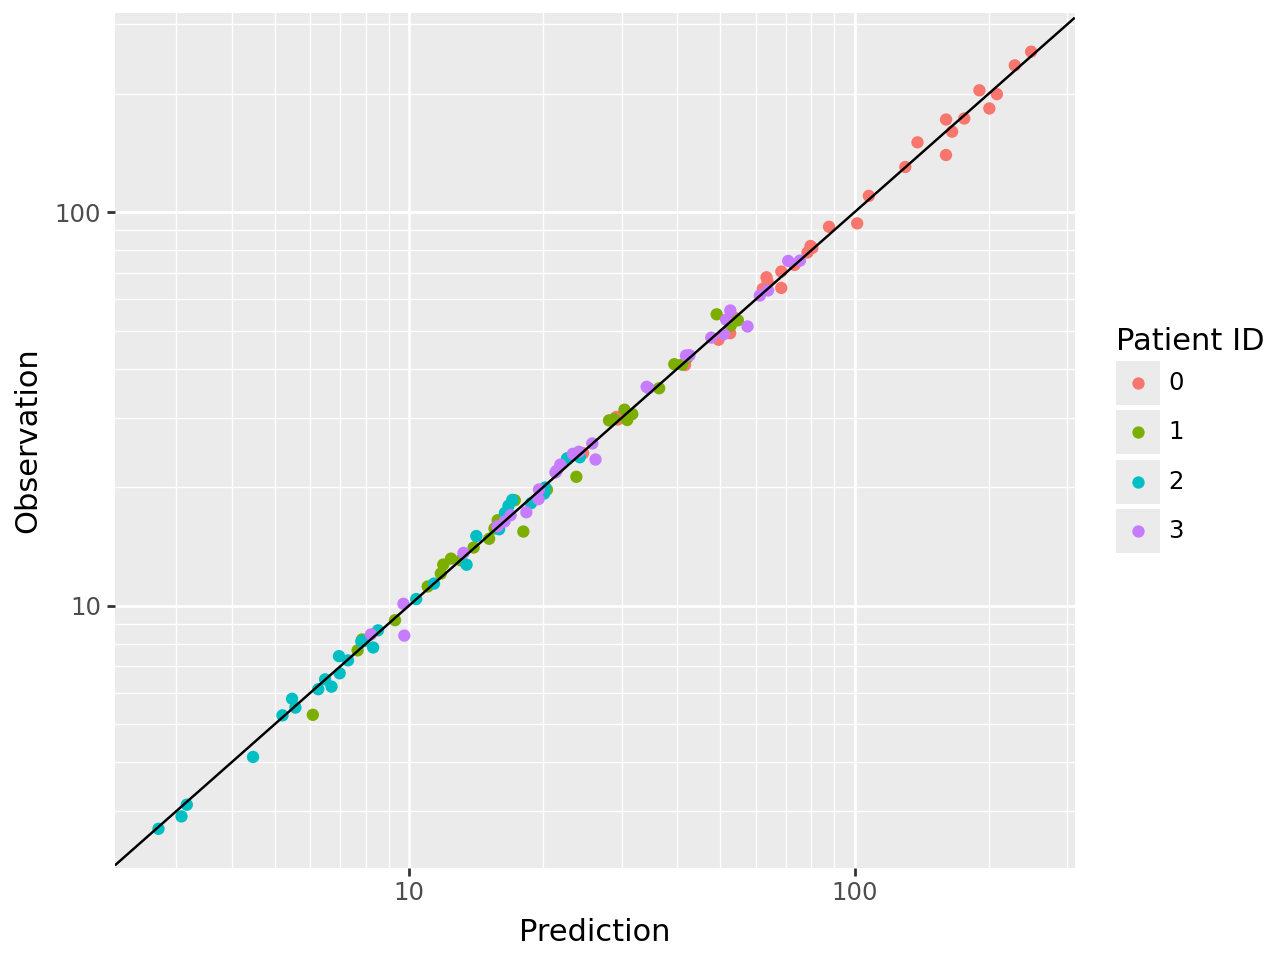

In [10]:
fig_PvsO = (ggplot()
            + geom_point(data = residuals, mapping = aes(x='prediction', y = 'measurement',
                                                         color = 'factor(ID)'))
            + geom_abline(intercept = 0, slope = 1)
            + scale_x_log10(breaks = 10.**np.arange(-20,20,1))
            + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
            + labs(x = 'Prediction', y = 'Observation', color = 'Patient ID')
            )

display(fig_PvsO)

## Plot histogram of residuals
- Use `geom_histogram` to plot the histogram of normalized residuals
    - Using `y = '..density..'` within the mapping automatically calculates the density based on the x mapping variable
- Use `geom_density` to calculate an approximation of the density curve of the normalized residuals
- Use `stat_function` to load in the `scipy` function for the probability density of a normal distribution
    - Set mean to 0 and standard deviation to 0.5 to approximate actual residual distribution
- Observe that residuals from best fit function roughly approximates a normal distribution
    - Note that original dummy data was generated with norm distributed noise

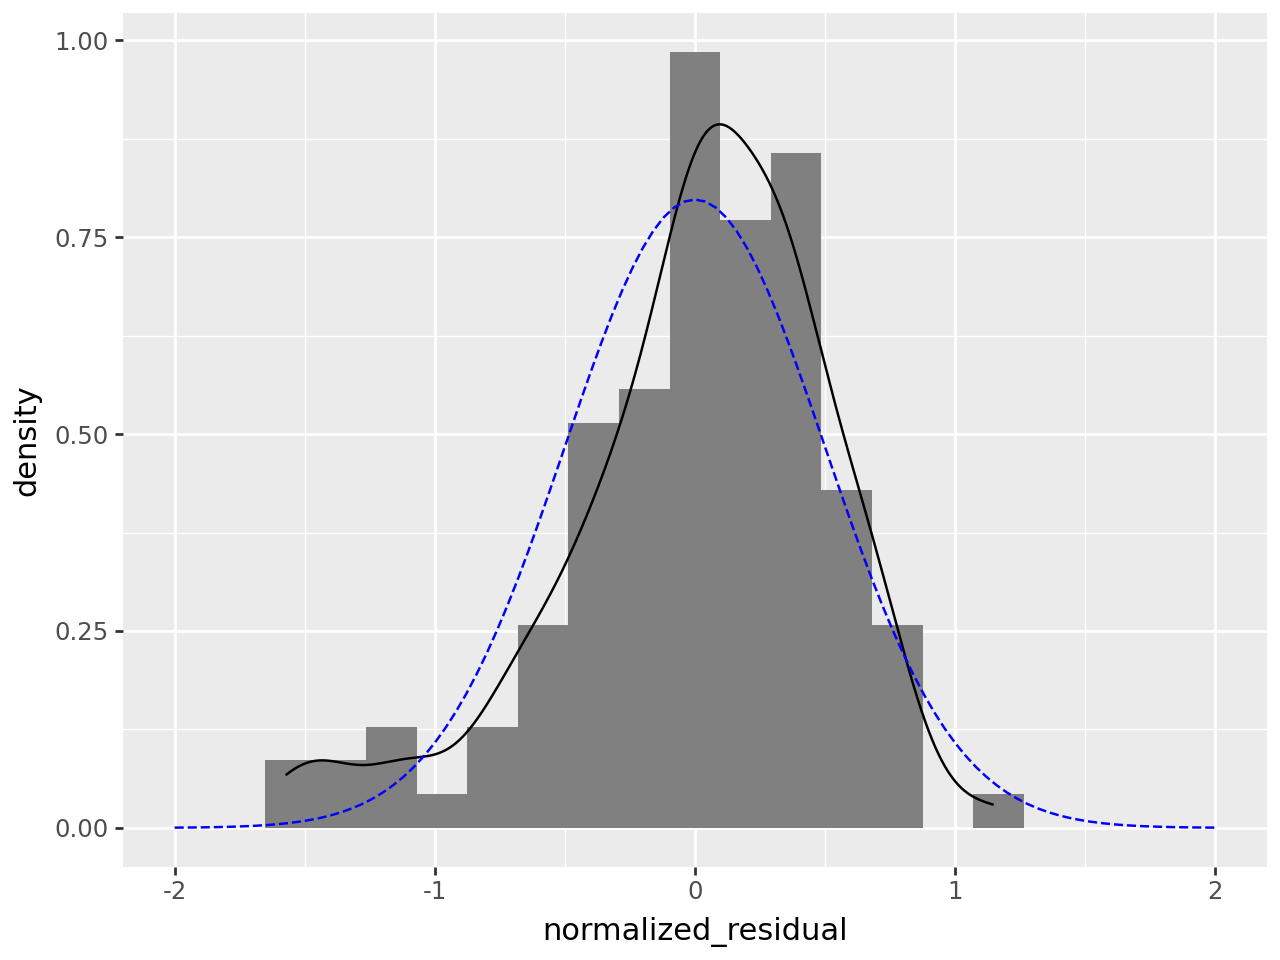

In [11]:
fig_hist = (ggplot()
            + geom_histogram(data = residuals,
                             mapping = aes(x = 'normalized_residual', y = '..density..'),
                             bins = 15, fill = 'grey')
            + geom_density(data = residuals,
                           mapping = aes(x = 'normalized_residual'),
                           color = 'black')
            + stat_function(fun = lambda x: stats.norm.pdf(x, loc = 0, scale = 0.5),
                            xlim = [-2,2], linetype = 'dashed', color = 'blue')
      )

display(fig_hist)

# Heat Map


## Tutorial Steps
1. Load the model, parameter set, and data.  
2. Scan over two model parameters for a single output and single time
3. Plot heat map

## Set up simulations

- Load the 2 compartment PK/RO example model from all the training videos and most other introductory notebooks is used here
- Data is loaded
- Load the same parameter table as a nominal set.
    - The dosing parameters from the model file are programmatically set to zero to ensure no double dosing

In [12]:
model = 'inputs/Models/2compartment_Ab.iqd'
Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')

Tdat = pd.read_csv('inputs/Data/Data_example_subset.csv')

Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')
Tpar = pd.concat([Tpar,
                  pd.DataFrame({'parameter':['Dose_amt_IV',
                                             'Dose_amt_SC']}).assign(unit = 'mg/kg',
                                                                     value = 0,
                                                                     is_fit = 'False')])

In [13]:
doses = [10]
times_single = [0]

Tdos = pd.DataFrame({'dose_mpk':doses,
                            'amounts': doses,
                            'times': [times_single] * len(list(doses))}).assign(time_unit = 'd', amount_unit = 'mg/kg',
                                                                                route = 'Dose_SC')
Tsim = Tdos[['dose_mpk']]

## Run 2d sensitivity analysis

- Create 2D parameter scan (See intro video and notebook for more details)
    - Choose affinity and receptor turnover half time as parameters to scan
    - Use the `fold_scan` option in the `simulate` function from the `abm` package
    - Select log distributed fold change for each parameter for this example
        - Different ranges and distributions of scanned values can be chosen based on what makes sense for a particular parameter

In [14]:
Tscan = abm.simulate(models = model,
        parameters = Tpar,
        doses = Tdos,
        simulations = Tsim,
        outputs = ['RO_c'],
        times = ['2:d'],
        scans = abm.fold_scan(Kd = list(np.logspace(-2,2, 17)))
                 * abm.fold_scan(Thalf_R = list(np.logspace(-2,2,17)))
                ).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

## Plot Heat Map

- Plot a heat map using Python's `plotnine` function
    - For log distributed values (as in this example) along an axis, use `scale_x_log10` and `scale_y_log10`
    - For linearly distributed values along an axis (not demonstrated), use `scale_x_continuous` and `scale_y_continuous`
    - For unevenly distributed values, non-numeric scan values, or to label exact scan values, use `scale_x_discrete` and `scale_y_discrete` along with the `factor(...)` argument when defining axis columns (demonstrated)

### Evenly spaced log values

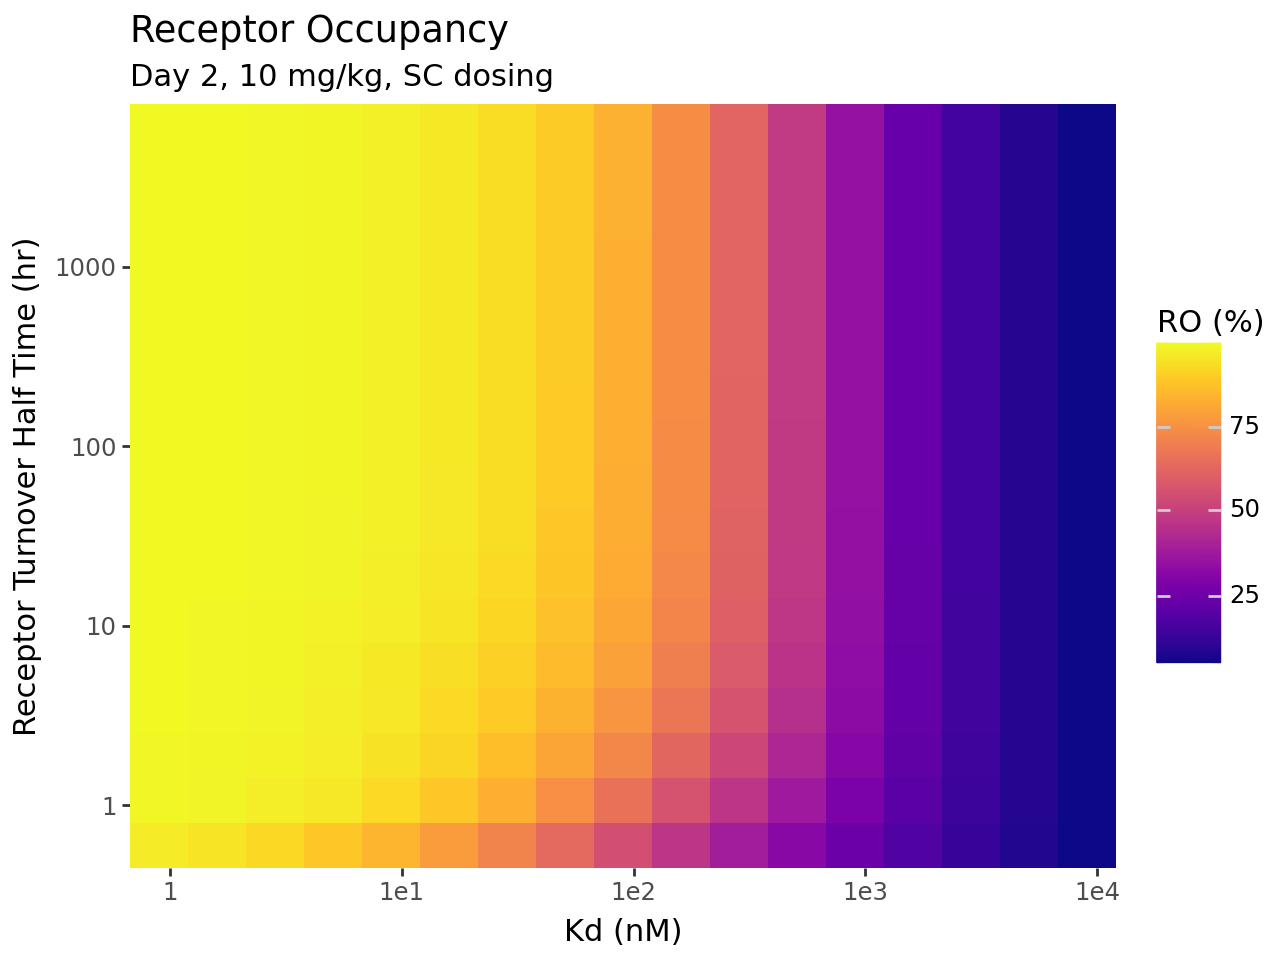

In [15]:
fig_heat = (ggplot()
            + geom_tile(data = Tscan,
                        mapping = aes(x='scan_0_value', y='scan_1_value', fill='value'))
            + scale_x_log10(expand=[0, 0])
            + scale_y_log10(expand=[0, 0])
            + scale_fill_cmap('plasma')
            + labs(x='Kd (nM)', y='Receptor Turnover Half Time (hr)', fill='RO (%)',
                   title='Receptor Occupancy', subtitle='Day 2, 10 mg/kg, SC dosing')
            )

display(fig_heat)

### Example labeling all scanned points exlicitly

Demonstration of using the `labels` argument with a rounding function on the axes.

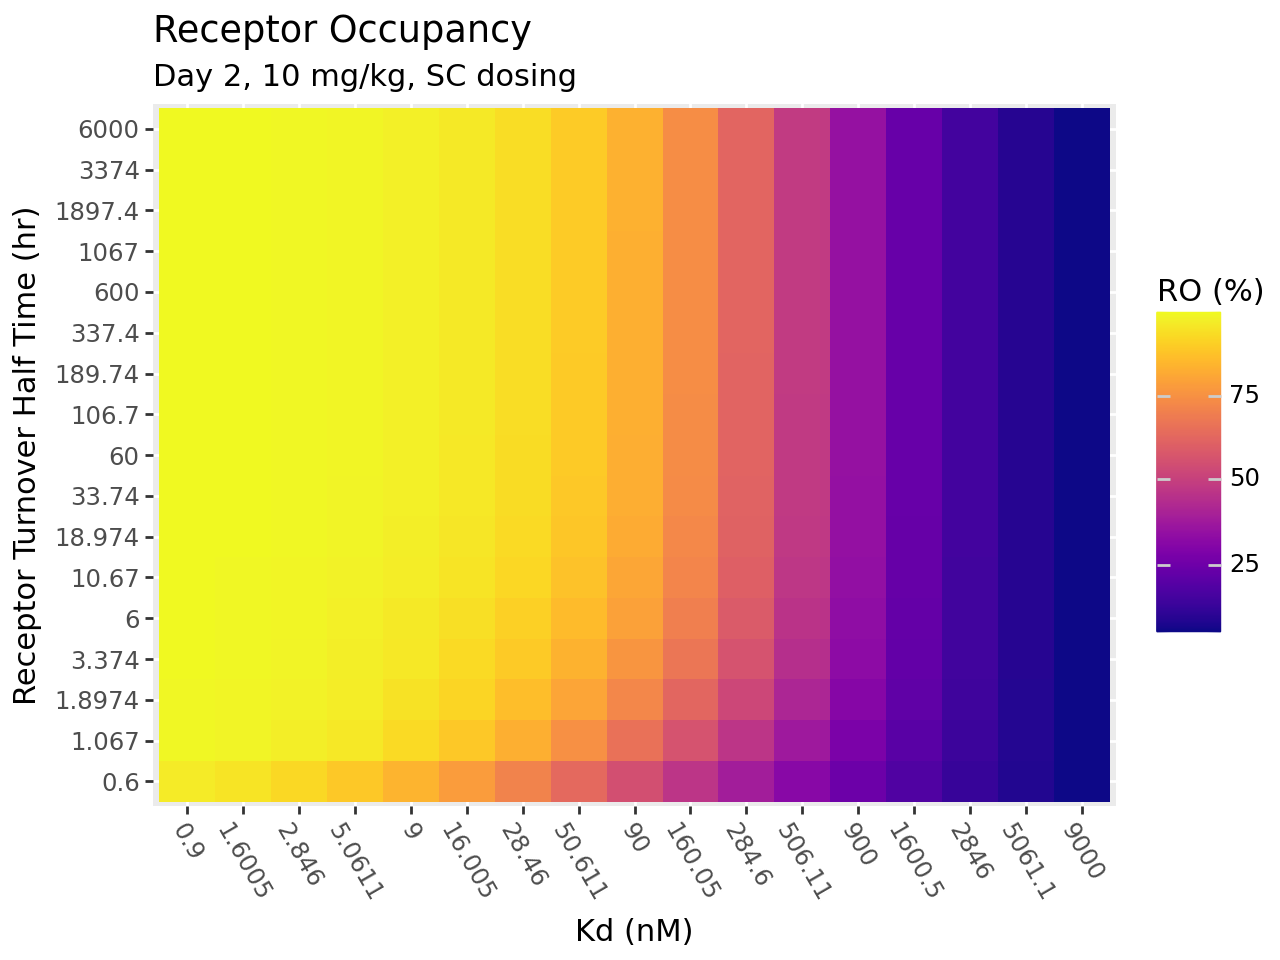

In [16]:
fig_heat_2 = (ggplot()
              + geom_tile(data = Tscan,
                          mapping = aes(x='factor(scan_0_value)', y='factor(scan_1_value)',
                                        fill='value'))
              + scale_x_discrete(labels=lambda xs: [f"{x:.5g}" for x in xs])
              + scale_y_discrete(labels=lambda xs: [f"{x:.5g}" for x in xs])
              + scale_fill_cmap('plasma')
              + labs(x='Kd (nM)', y='Receptor Turnover Half Time (hr)', fill='RO (%)',
                     title='Receptor Occupancy', subtitle='Day 2, 10 mg/kg, SC dosing')
              + theme(axis_text_x=element_text(rotation=-60))
             )

display(fig_heat_2)

# Text Labels

## Tutorial Steps
1. Display Heat map from previous section
2. Add labels to it

## Display heat map
- Heat map in the previous section was defined with the variable `fig_heat`
- display `fig_heat` to show baseline figure
    - This now provides a plot object that can be added to using the `plotnine` grammar

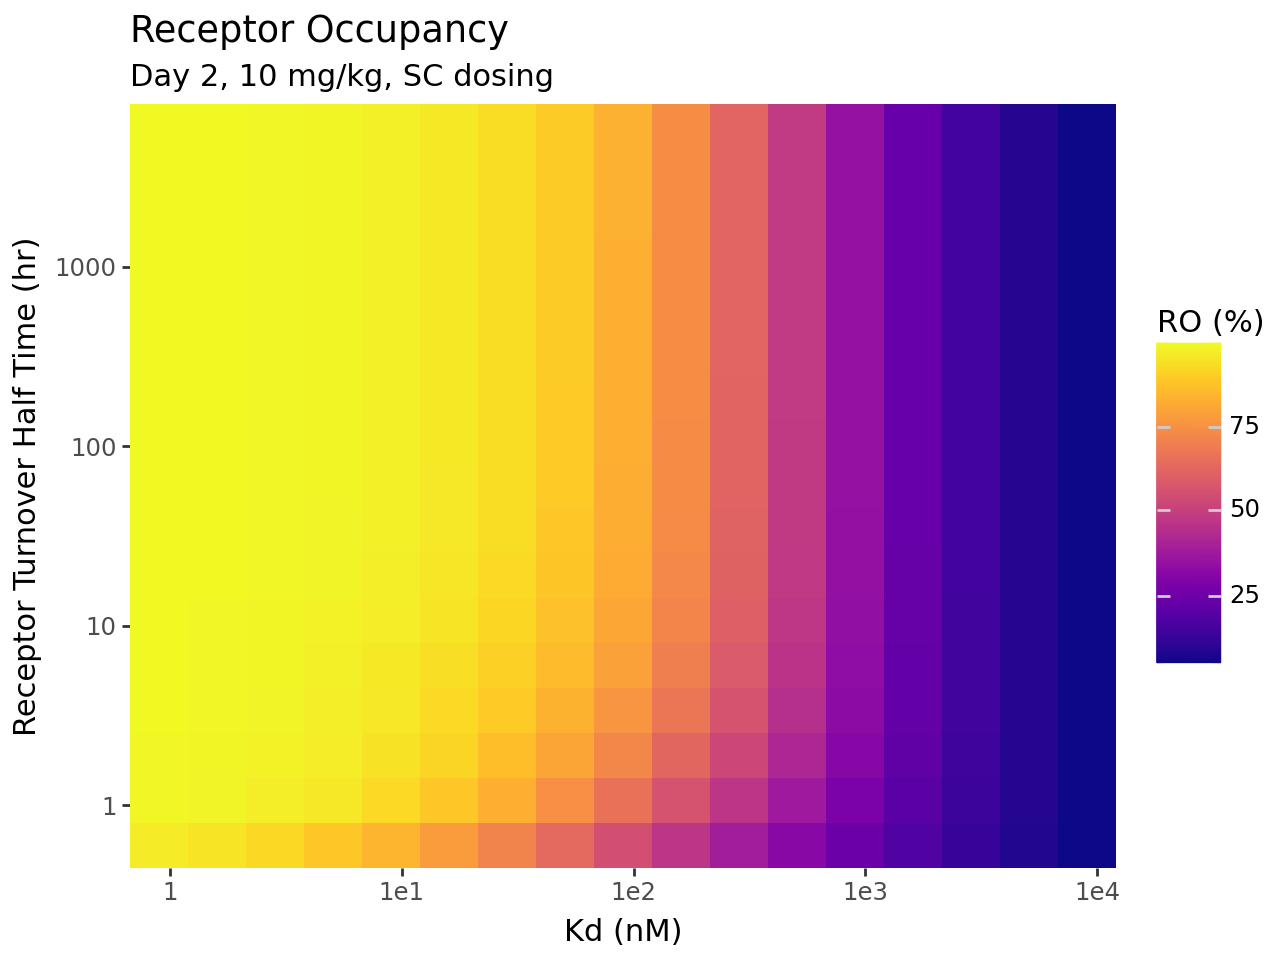

In [17]:
display(fig_heat)

## Add Labels for nominal parameter set
- Extract nominal parameter set and output from scan results
- Add point and label marking nominal values onto heat map

In [18]:
Tnom = Tscan.copy().query('scan_0_fold == 1 and scan_1_fold == 1')
Tnom['label'] = Tnom.apply(lambda x: f'{np.around(x.value, 2)}%', axis = 1)

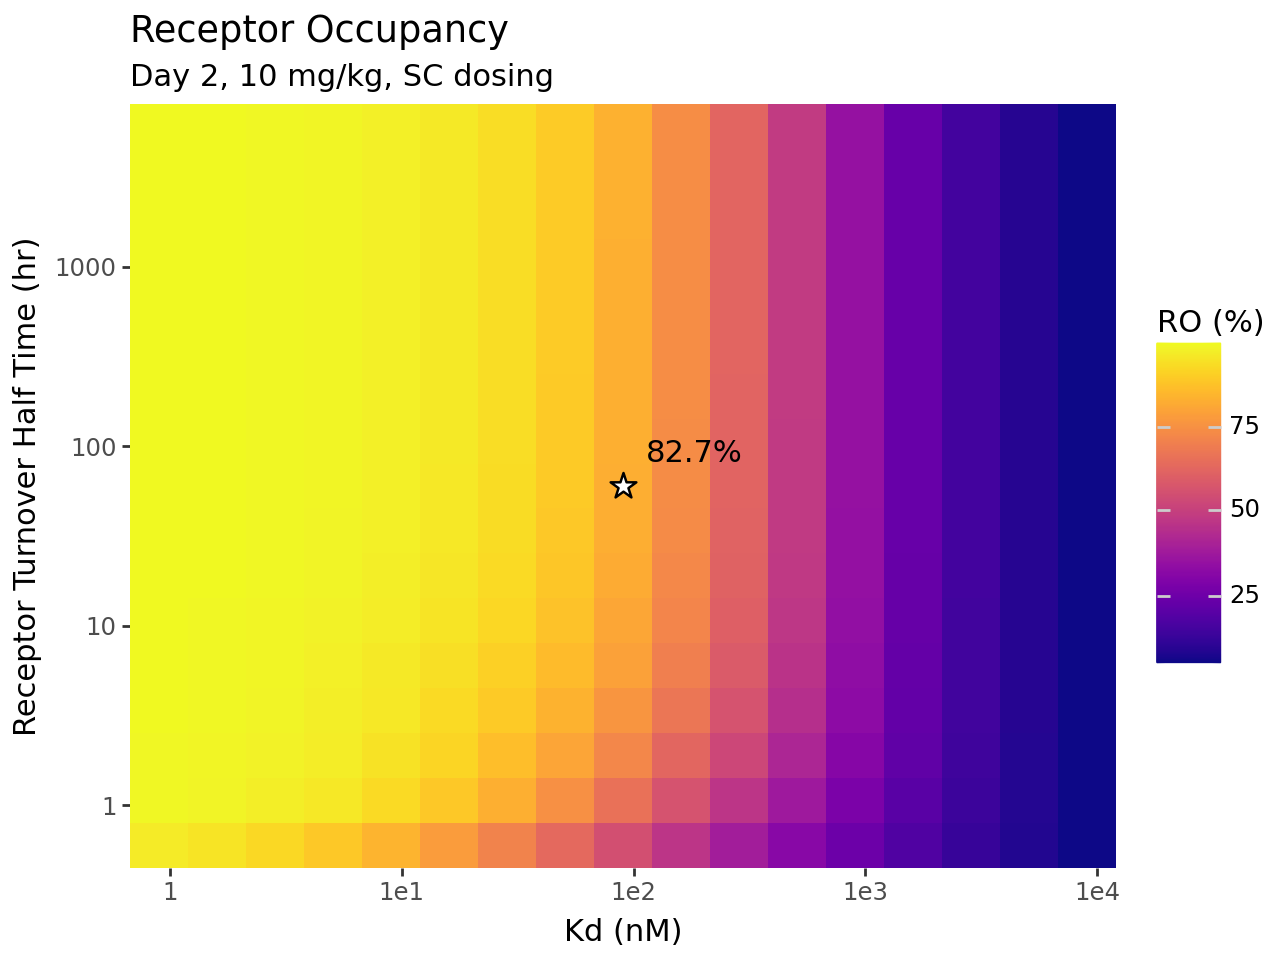

In [19]:
fig_heat += geom_point(data = Tnom, mapping = aes(x = 'scan_0_value', y = 'scan_1_value'),
                       fill = 'white', color = 'black', shape = '*', size = 5)
fig_heat += geom_text(data = Tnom, mapping = aes(x = 'scan_0_value', y = 'scan_1_value',
                                                 label = 'label'),
                      ha = 'left', va = 'bottom', nudge_x = 0.1, nudge_y = 0.1)

display(fig_heat)